In [1]:
import tensorflow as tf
import tensorflow_probability as tfp

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn import cluster, datasets, mixture
from sklearn.preprocessing import StandardScaler

from scipy.stats import norm
import matplotlib.mlab as mlab

tfk = tf.keras
tfkl = tfk.layers
tfd = tfp.distributions
tfb = tfp.bijectors

#sns.set_style("white")
#sns.set_context("notebook")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

In [2]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band

In [3]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [106]:
images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_2.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_2.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_2.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_2.csv')

ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))

In [107]:
X = np.zeros((len(e1),2))
X[:,0]=e1
X[:,1]=e2

### Design a normalizing flow

code from: https://dirmeier.github.io/etudes/normalizing_flows.html

In [108]:
def make_degrees(p, hidden_dims):
    m = [tf.constant(range(1, p + 1))]
    for dim in hidden_dims:                
        n_min = min(np.min(m[-1]), p - 1)
        degrees = (np.arange(dim) % max(1, p - 1) + min(1, p - 1))
        degrees = tf.constant(degrees, dtype="int32")
        m.append(degrees)
    return m

def make_masks(degrees):
    masks = [None] * len(degrees)
    for i, (ind, outd) in enumerate(zip(degrees[:-1], degrees[1:])):
        masks[i] = tf.cast(ind[:, tf.newaxis] <= outd, dtype="float32")        
    masks[-1] = tf.cast(degrees[-1][:, np.newaxis] < degrees[0], dtype="float32")
    return masks

def make_constraint(mask):    
    def _constraint(x):
        return mask * tf.identity(x)
    return _constraint

def make_init(mask):
    def _init(shape, dtype=None):
        return mask * tf.keras.initializers.GlorotUniform(23)(shape)
    return _init

def make_network(p, hidden_dims, params):
    masks = make_masks(make_degrees(p, hidden_dims))    
    masks[-1] = tf.tile(masks[-1][..., tf.newaxis], [1, 1, params])
    masks[-1] = tf.reshape(masks[-1], [masks[-1].shape[0], p * params])
    
    network =  tf.keras.Sequential([
        tf.keras.layers.InputLayer((p,))
    ])
    for dim, mask in zip(hidden_dims + [p * params], masks):
        layer = tf.keras.layers.Dense(
            dim,
            kernel_constraint=make_constraint(mask),
            kernel_initializer=make_init(mask),
            activation=tf.nn.leaky_relu)
        network.add(layer)    
    network.add(tf.keras.layers.Reshape([p, params]))#network.add(tf.keras.layers.Reshape([p, params]))
    
    return network

In [109]:
class MAF(tfb.Bijector):
    def __init__(self, shift_and_log_scale_fn, name="maf"):
        super(MAF, self).__init__(forward_min_event_ndims=1, name=name)
        self._shift_and_log_scale_fn = shift_and_log_scale_fn
        
    def _shift_and_log_scale(self, y):
        params = self._shift_and_log_scale_fn(y)          
        shift, log_scale = tf.unstack(params, num=2, axis=-1)
        return shift, log_scale
        
    def _forward(self, x):
        y = tf.zeros_like(x, dtype=tf.float32)
        for i in range(x.shape[-1]):            
            shift, log_scale = self._shift_and_log_scale(y)            
            y = x * tf.math.exp(log_scale) + shift
        return y

    def _inverse(self, y):
        shift, log_scale = self._shift_and_log_scale(y)
        return (y - shift) * tf.math.exp(-log_scale)

    def _inverse_log_det_jacobian(self, y):
        _, log_scale = self._shift_and_log_scale(y)
        return -tf.reduce_sum(log_scale, axis=self.forward_min_event_ndims)

In [110]:
hidden_dim = [256,256]  
layers = 10
bijectors = []
for i in range(0, layers):
    made = make_network(2, hidden_dim, 2)
    bijectors.append(MAF(made))
    bijectors.append(tfb.Permute(permutation=[1, 0])) 
    
bijectors = tfb.Chain(bijectors=list(reversed(bijectors[:-1])))

In [111]:
distribution = tfd.TransformedDistribution(
    distribution=tfd.Normal(loc=0., scale=1.),
    bijector=bijectors,
    event_shape=[2]
)


In [112]:
distribution

<tfp.distributions.TransformedDistribution 'chain_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_mafNormal' batch_shape=[] event_shape=[2] dtype=float32>

In [113]:
x_ = tfkl.Input(shape=(2,), dtype=tf.float32)
log_prob_ = distribution.log_prob(x_)
model = tfk.Model(x_, log_prob_)

model.compile(optimizer=tf.optimizers.Adam(), loss=lambda _, log_prob: -log_prob)

model.summary()

Model: "model_10"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_96 (InputLayer)           [(None, 2)]          0                                            
__________________________________________________________________________________________________
sequential_84 (Sequential)      (None, 2, 2)         67588       input_96[0][0]                   
                                                                 input_96[0][0]                   
                                                                 input_96[0][0]                   
__________________________________________________________________________________________________
tf_op_layer_unstack_195 (Tensor [(None, 2), (None, 2 0           sequential_84[1][0]              
___________________________________________________________________________________________

In [114]:
_ = model.fit(x=X,
              y=np.zeros((X.shape[0], 0), dtype=np.float32),
              batch_size= X.shape[0],
              epochs=3000,
              steps_per_epoch=1,
              verbose=1,
              shuffle=False)

Train on 10000 samples
Epoch 1/3000
10000/10000 [==============================] - 12s 1ms/sample - loss: 1.9835
Epoch 2/3000
10000/10000 [==============================] - 1s 117us/sample - loss: 1.8518
Epoch 3/3000
10000/10000 [==============================] - 1s 91us/sample - loss: 1.7979
Epoch 4/3000
10000/10000 [==============================] - 1s 97us/sample - loss: 1.7449
Epoch 5/3000
10000/10000 [==============================] - 1s 91us/sample - loss: 1.6901
Epoch 6/3000
10000/10000 [==============================] - 1s 91us/sample - loss: 1.6314
Epoch 7/3000
10000/10000 [==============================] - 1s 98us/sample - loss: 1.5673
Epoch 8/3000
10000/10000 [==============================] - 1s 108us/sample - loss: 1.4966
Epoch 9/3000
10000/10000 [==============================] - 1s 87us/sample - loss: 1.4189
Epoch 10/3000
10000/10000 [==============================] - 1s 91us/sample - loss: 1.3350
Epoch 11/3000
10000/10000 [==============================] - 1s 87us/sampl

In [100]:
distribution.sample(1)

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[ 0.04310478, -0.0561247 ]], dtype=float32)>

In [101]:
tf.convert_to_tensor(distribution.sample(1))

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[-0.03244055, -0.07890765]], dtype=float32)>

In [102]:
samples = distribution.sample(10000)

In [103]:
samples.shape

TensorShape([10000, 2])

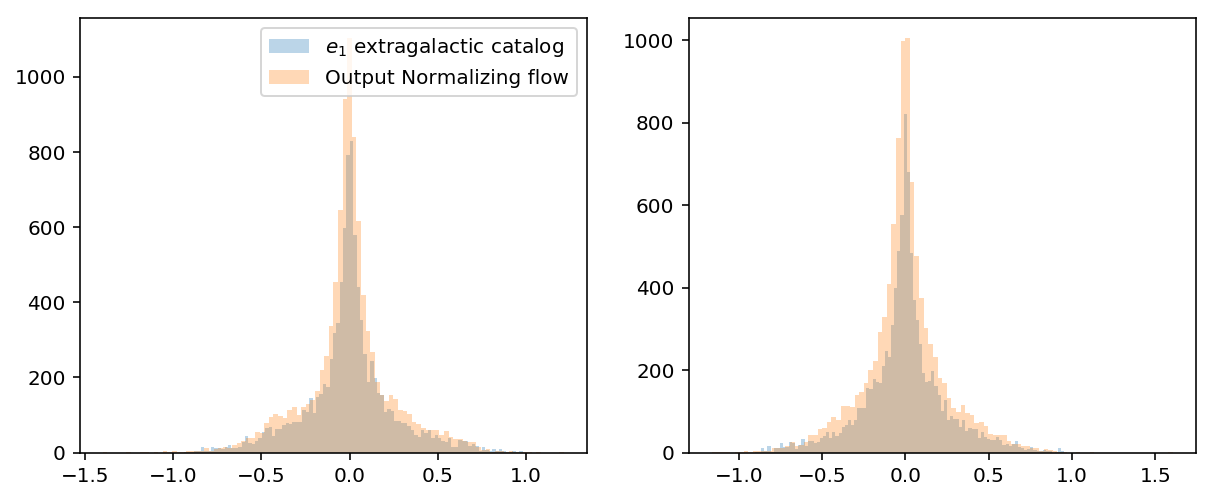

In [104]:
fig, axes = plt.subplots(1,2,figsize = (10,4))

_ = axes[0].hist(e1, bins = 100, alpha = 0.3, label = '$e_1$ extragalactic catalog')
_ = axes[0].hist(samples[:,0], bins = 100, alpha = 0.3, label = 'Output Normalizing flow')

_ = axes[1].hist(e2, bins = 100, alpha = 0.3)
_ = axes[1].hist(samples[:,1], bins = 100, alpha = 0.3)

axes[0].legend()

In [105]:
model.save_weights('normalizing_flow_weights/cp-{epoch:04d}.ckpt')
#model.save('normalizing_flow_weights/my_model')

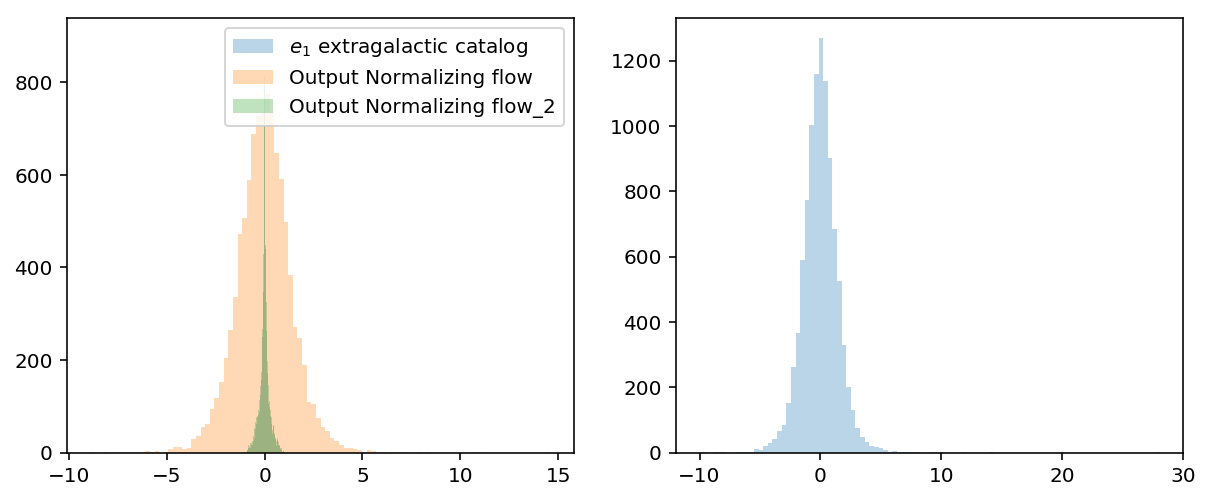

In [96]:
fig, axes = plt.subplots(1,2,figsize = (10,4))

_ = axes[0].hist(e1, bins = 100, alpha = 0.3, label = '$e_1$ extragalactic catalog')
_ = axes[0].hist(test[:,0], bins = 100, alpha = 0.3, label = 'Output Normalizing flow')
_ = axes[0].hist(test_2[:,0], bins = 100, alpha = 0.3, label = 'Output Normalizing flow_2')

#_ = axes[1].hist(e2, bins = 100, alpha = 0.3)
_ = axes[1].hist(test[:,1], bins = 100, alpha = 0.3)

axes[0].legend()

In [59]:
def load_nf(loading_path):

    hidden_dim = [256,256]  
    layers = 3
    bijectors = []
    for i in range(0, layers):
        made = make_network(2, hidden_dim, 2)
        bijectors.append(MAF(made))
        bijectors.append(tfb.Permute(permutation=[1, 0])) 
        
    bijectors = tfb.Chain(bijectors=list(reversed(bijectors[:-1])))

    distribution = tfd.TransformedDistribution(
        distribution=tfd.Normal(loc=0., scale=1.),
        bijector=bijectors,
        event_shape=[2])

    x_ = tfkl.Input(shape=(2,), dtype=tf.float32)
    log_prob_ = distribution.log_prob(x_)
    model = tfk.Model(x_, log_prob_)

    #model.compile(optimizer=tf.optimizers.Adam(), loss=lambda _, log_prob: -log_prob)

    model.summary()
    #latest = tf.train.latest_checkpoint(loading_path)
    model.load_weights(loading_path)

    return model, distribution

In [60]:
loading_path = '/pbs/throng/lsst/users/barcelin/parameter_estimation/notebooks/parameter_estimation/normalizing_flow_weights/cp-{epoch:04d}.ckpt'
nf, distrib = load_nf(loading_path)
nf.summary()

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_66 (InputLayer)           [(None, 2)]          0                                            
__________________________________________________________________________________________________
sequential_58 (Sequential)      (None, 2, 2)         67588       input_66[0][0]                   
                                                                 input_66[0][0]                   
                                                                 input_66[0][0]                   
__________________________________________________________________________________________________
tf_op_layer_unstack_138 (Tensor [(None, 2), (None, 2 0           sequential_58[1][0]              
____________________________________________________________________________________________

In [39]:
test = distribution.sample(10000)
test_2 = distrib.sample(10000)

W0607 15:22:55.932812 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer
W0607 15:22:55.934227 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer.iter
W0607 15:22:55.935064 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer.beta_1
W0607 15:22:55.935819 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer.beta_2
W0607 15:22:55.936585 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer.decay
W0607 15:22:55.937333 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer.learning_rate
W0607 15:22:55.938076 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer's state 'm' for (root).layer_with_weights-0.layer_with_weights-0.kernel
W0607 15:22:55.938834 139688838858560 util.py:144] Unresolved object in checkpoint: (root).optimizer's state 'm' for (root).layer_with_weights-0.layer_with_weights-0.bias
W0607 15:22

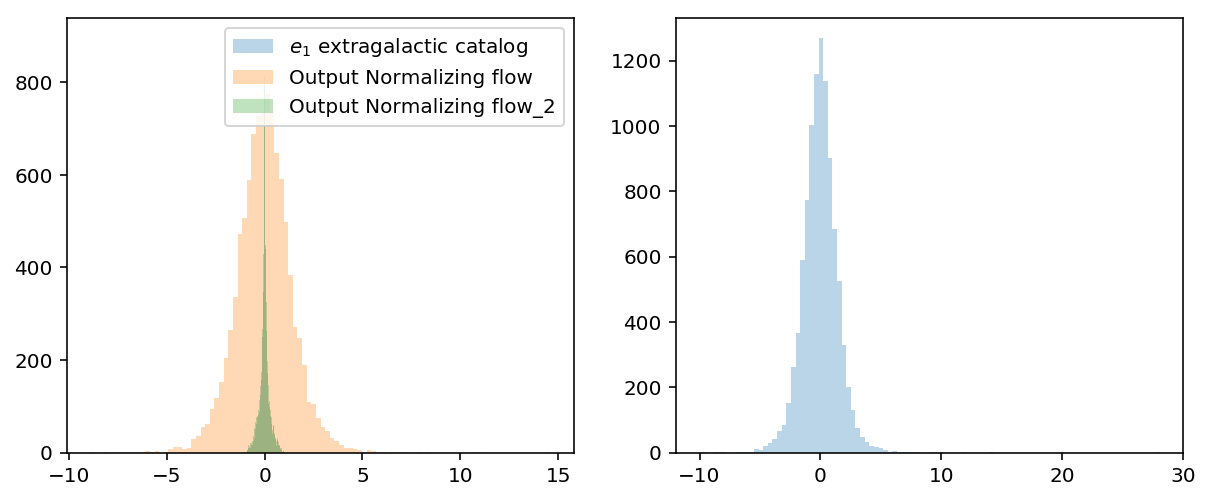

In [41]:
fig, axes = plt.subplots(1,2,figsize = (10,4))

_ = axes[0].hist(e1, bins = 100, alpha = 0.3, label = '$e_1$ extragalactic catalog')
_ = axes[0].hist(test[:,0], bins = 100, alpha = 0.3, label = 'Output Normalizing flow')
_ = axes[0].hist(test_2[:,0], bins = 100, alpha = 0.3, label = 'Output Normalizing flow_2')

#_ = axes[1].hist(e2, bins = 100, alpha = 0.3)
_ = axes[1].hist(test[:,1], bins = 100, alpha = 0.3)

axes[0].legend()

In [43]:
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(2), scale=1),
                        reinterpreted_batch_ndims=1)

In [90]:
prior.sample(1)

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[-0.8402563 ,  0.62681085]], dtype=float32)>

In [47]:
prior, tfd.Independent(distrib, reinterpreted_batch_ndims=0)

(<tfp.distributions.Independent 'IndependentNormal' batch_shape=[] event_shape=[2] dtype=float32>,
 <tfp.distributions.Independent 'Independentchain_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_maf_of_permute_of_mafNormal' batch_shape=[] event_shape=[2] dtype=float32>)

In [12]:
###############
import sys

sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import utils, model

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Reshape, Flatten, BatchNormalization, Conv2D, Conv3D, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda,  concatenate

W0607 14:29:29.353203 140001490536256 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [13]:
######## Parameters
nb_of_bands = 6
batch_size = 512

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

In [14]:
saving_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/v_param_from_vae'
step_size = 150


steps_per_epoch = int(100000/batch_size)
validation_steps = int(20000/batch_size)

root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/training/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

In [15]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(encoded_size), scale=1),reinterpreted_batch_ndims=1)


vae = model.create_model_wo_ls_peak_pooling_vae_4(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)
path_output = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_vae_no_psf_noisy/loss/'
latest = tf.train.latest_checkpoint(path_output)
vae.load_weights(latest)

encoder = Model([vae.layers[0].input,vae.layers[-2].input], vae.layers[20].output) #vae.layers[44].output[0]

input_layer_1 = Input(shape=(input_shape)) 
input_layer_2 = Input(shape=(input_shape)) 

out = encoder([input_layer_1,input_layer_2])

W0607 14:30:23.819253 140001490536256 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0607 14:30:24.083391 140001490536256 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [16]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(32), scale=1.),reinterpreted_batch_ndims=1)

def param_estimation_net(vae, encoder, final_dim, nf):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 
    
    encoder.trainable = False
    nf.trainable = False

    h = encoder([input_layer_1,input_layer_2])
    
    #h = tfp.layers.MultivariateNormalTriL(32,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.01))(tf.cast(h,tf.float32))

    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = None)(h)
    h = PReLU()(h)
    h = Dense(128, activation = None)(h)
    h = PReLU()(h)
    
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    #h = Dense(2)(h)#
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)
    h = nf([h])
    
    return Model((input_layer_1, input_layer_2), h)

In [17]:
param_estim_net = param_estimation_net(vae, encoder, final_dim, nf)
param_estim_net.summary()

RuntimeError: Attempting to capture an EagerTensor without building a function.

In [ ]:
loading_path = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_param_from_vae/loss/'
latest = tf.train.latest_checkpoint(loading_path)
param_estim_net.load_weights(latest)